# 05 — The female ladder, and when 9c arrives

Notebook 02 works through a question in two stages. First it does the tempting
thing: fit six curve shapes to the men's milestones, hold the last one back, and
crown whichever shape predicts it best. Then it shows that this is the wrong way
to choose — the winner of that contest turns out to be the *worst* forecaster in
the set once it is tested properly — and replaces it with a harder test that the
simplest method of all wins.

This notebook runs the same two stages on the female ladder, and gets the same
answer twice over. **The shape that wins on one held-out rung finishes seventh
of ten when it has to predict five.**

Three things differ from notebook 02, and each is a property of the data rather
than a choice:

- **One convention, not two.** `as_proposed` / `as_consensus` splits the men's
  ladder because a first ascentionist proposes a grade that later repeats may
  move. A female milestone is almost always a *repeat*, made years to decades
  after the first ascent, by which time the grade **is** the consensus grade.
  There is no second reading to carry.
- **The ladder is not derived from the scrape.** It cannot be: the scrape has no
  gender field, and it kept only the first-ascent row per climb — the ascents
  that define this ladder are exactly the rows it does not have. The table lives
  in `sportgradehistory.female_milestones` as a curated, cited dataset, and is
  checked against the scrape below.
- **Both open grades are extrapolations, and one is further out than the
  other.** The ladder stops at 9b+ (Excalibur, April 2025), so 9c is one step
  past the data and 9c+ is two. Only the one-step question gets tested here;
  9c+ inherits no track record, and is labelled that way throughout.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from sportgradehistory import config
from sportgradehistory.female_milestones import (
    MILESTONE_START, crosscheck, female_ladder, ordering_notes)
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal

BASE = french_ordinal(MILESTONE_START)                  # 8a
LADDER = list(FRENCH_SCALE[BASE:BASE + 11]) + ["9c+"]   # 8a … 9c, then off-scale

lad = female_ladder()
ORIGIN = lad["year_frac"].iloc[0]                       # Come Back, 1986.0
lad = lad.assign(months=(lad["year_frac"] - ORIGIN) * 12)

lad.to_csv(config.PROCESSED_DIR / "female_milestones.csv", index=False)
print(lad[["grade", "route", "climber", "crag", "country", "ascent",
           "date_precision", "steps"]].to_string(index=False))

grade              route              climber                   crag country     ascent date_precision  steps
   8a          Come Back         Luisa Iovane         Val San Nicolo     ITA 1986-01-01           year      0
  8a+            Choucas Catherine Destivelle                  Buoux     FRA 1988-03-01          month      1
   8b         Sortileges   Isabelle Patissier               Le Cimai     FRA 1988-01-01           year      2
  8b+     Masse Critique            Lynn Hill                  Cimai     FRA 1990-01-01           year      3
   8c        Honky Tonky    Josune Bereziartu                  Onate     ESP 1998-05-01          month      4
  8c+     Honky Tonk Mix    Josune Bereziartu                  Onate     ESP 2000-06-01          month      5
   9a       Bain de Sang    Josune Bereziartu             Saint Loup     SUI 2002-10-29            day      6
  9a+          La Rambla          Margo Hayes                Siurana     ESP 2017-02-26            day      7
   9b La P

## Does the scrape agree with the table?

The ladder comes from outside this repository, so every claim it makes that the
scrape *can* check is checked. The site records each route's first ascent, not
the female one, so climber and date will differ by design — the column that has
to agree is the **grade**.

In [2]:
check = crosscheck()
print(check[["grade", "route", "site_name", "site_grade", "grade_agrees",
             "site_fa_climber", "site_fa_date", "is_own_fa"]].to_string(index=False))

carried = check["grade_agrees"].notna()
print(f"\n{int(check.loc[carried, 'grade_agrees'].sum())}/{int(carried.sum())} routes "
      f"the site carries agree on grade; {int((~carried).sum())} are not in the scrape "
      "at all (Come Back, Choucas), so those two rows rest on the external source alone.")
print(f"{int(check['is_own_fa'].sum())} of the ten are the climber's own first ascent "
      "— both Bereziartu's, at Oñate.")

grade              route          site_name site_grade grade_agrees          site_fa_climber  site_fa_date is_own_fa
   8a          Come Back                NaN        NaN         None                      NaN           NaN      None
  8a+            Choucas                NaN        NaN         None                      NaN           NaN      None
   8b         Sortileges        Sortillèges         8b         True    Jean-Baptiste Tribout 30th Apr 1986     False
  8b+     Masse Critique     Masse Critique        8b+         True    Jean-Baptiste Tribout 10th Dec 1989     False
   8c        Honky Tonky        Honky Tonky         8c         True        Josune Bereziartu      Apr 1998      True
  8c+     Honky Tonk Mix          Honky Mix        8c+         True        Josune Bereziartu 30th Jun 2000      True
   9a       Bain de Sang       Bain de Sang         9a         True              Fred Nicole      Sep 1993     False
  9a+          La Rambla          La Rambla        9a+         T

**Every grade the scrape can check, it confirms.** Two 1980s routes are missing
from the site entirely, which is the era where its record is thinnest.

The `is_own_fa` column is worth a look on its own: eight of the ten female
milestones are **repeats of routes men established**, sometimes decades later
(La Rambla — first ascent 2003, first female ascent 2017). The exceptions are
Josune Bereziartu's own first ascents at Oñate, Honky Tonky (8c, 1998) and Honky
Tonk Mix (8c+, 2000). She is the only woman on this list who set a grade
milestone on a route nobody had climbed.

### One ordering the dates cannot settle

In [3]:
notes = ordering_notes(lad)
print(notes.to_string(index=False) if not notes.empty else "none")

lower_grade lower_route lower_date upper_grade upper_route upper_date      kind  inversion_years  anchoring_artifact
        8a+     Choucas   Mar 1988          8b  Sortileges       1988 inversion             0.16                True


Choucas (8a+) is dated March 1988; Sortilèges (8b) is dated only "1988". A
year-only date is anchored to 1 January everywhere in this repository, so the 8b
rung lands *two months before* the 8a+ rung it should follow. That is an
artifact of the anchoring, not evidence that the 8b came first, and it is
reported rather than quietly fixed — the same treatment the men's table gives
its own unresolved pairs. Its effect on everything below is two months on one of
ten points.

## First, the tempting test

Six shapes, fitted to the first nine rungs (8a → 9b), each asked for the tenth.
The ladder is fitted **sideways** — grade on the x axis, time on the y — so that
a prediction comes out as a date, which is the quantity anyone actually wants.
Time is counted in months since Come Back (1 Jan 1986).

- **Poly 1–4** — a straight line, then curves allowed one, two and three bends.
  Fitted to nine points, so even the wiggliest has four points of slack.
- **Exponential** — the shape that accelerates without limit.
- **Logarithmic** — the shape that flattens towards a ceiling.

Train on 8a → 9b. Predict 9b+. Score against Excalibur, 5 April 2025.

In [4]:
def exp_model(g, a, b, k):
    return a * np.exp(b * g) + k


def log_model(g, a, b):
    return a * np.log(g + 1) + b


def build_models(x, y):
    # The same six shapes, fitted to whatever slice of the ladder is passed.
    out = {}
    for deg in (1, 2, 3, 4):
        out[f"Poly {deg}"] = (lambda g, k=np.polyfit(x, y, deg): np.polyval(k, g))
    log_b, log_a = np.polyfit(x, np.log(y + 1.0), 1)        # seed the optimiser
    p_exp, _ = curve_fit(exp_model, x, y, p0=(np.exp(log_a), log_b, -1.0),
                         maxfev=200000)
    out["Exponential"] = lambda g, p=p_exp: exp_model(g, *p)
    p_log, _ = curve_fit(log_model, x, y, p0=(100.0, 0.0), maxfev=200000)
    out["Logarithmic"] = lambda g, p=p_log: log_model(g, *p)
    return out


train = lad[lad["steps"] <= 8]                              # 8a … 9b
x, y = train["steps"].to_numpy(float), train["months"].to_numpy(float)
actual_9bp = float(lad.loc[lad["steps"] == 9, "months"].iloc[0])
models = build_models(x, y)

rows = []
for name, f in models.items():
    pred = float(f(9.0))
    rows.append({
        "model": name,
        "9b+ predicted": ORIGIN + pred / 12,
        "miss (years)": (pred - actual_9bp) / 12,
        "abs_miss": abs(pred - actual_9bp) / 12,
    })
holdout = pd.DataFrame(rows).sort_values("abs_miss").reset_index(drop=True)

print(f"actual 9b+: Excalibur, {ORIGIN + actual_9bp / 12:.2f}\n")
print(holdout.drop(columns="abs_miss").round(2).to_string(index=False))

actual 9b+: Excalibur, 2025.26

      model  9b+ predicted  miss (years)
     Poly 3        2025.69          0.43
     Poly 2        2028.14          2.88
Exponential        2029.49          4.23
     Poly 4        2020.41         -4.84
     Poly 1        2019.93         -5.33
Logarithmic        2011.33        -13.93


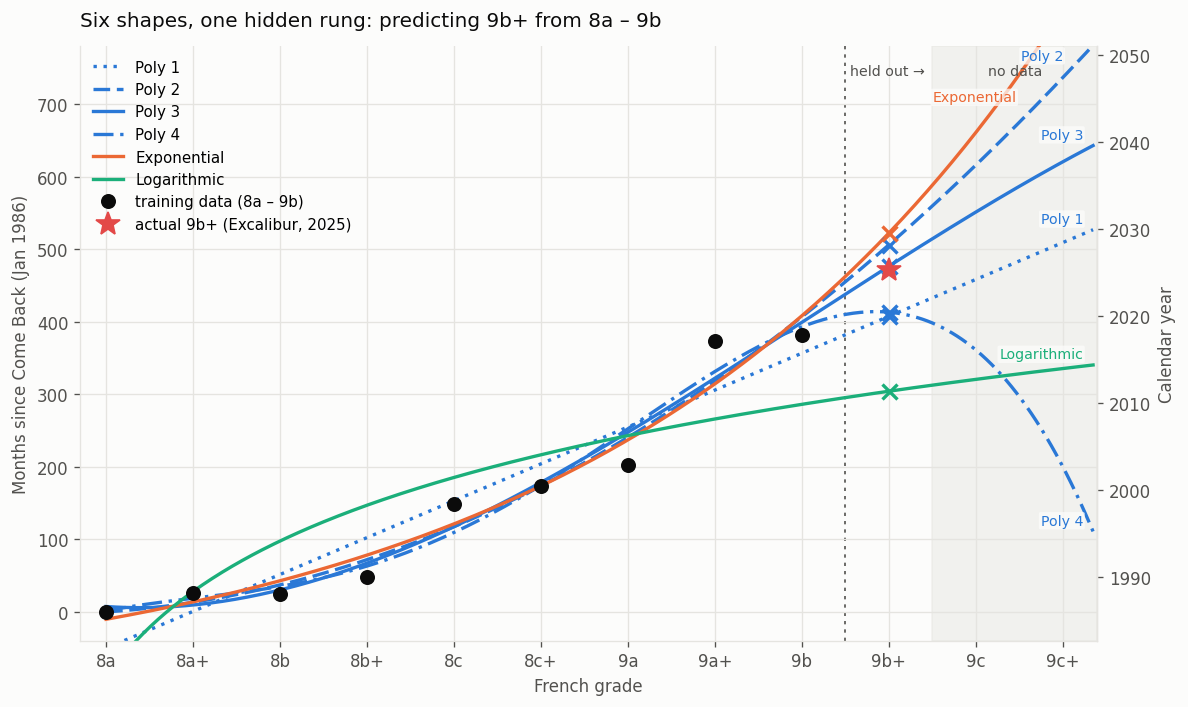

In [5]:
import matplotlib.pyplot as plt

PAPER, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"

# Polynomial degree is ordinal, so the four polys are one hue separated by dash
# pattern and direct labels; exp and log are different families and get their
# own hues. Three hues, not six: adjacent steps of a blue ramp are not
# reliably separable, and the dash pattern carries the degree anyway.
STYLE = {
    "Poly 1":      (BLUE,   (0, (1, 2))),
    "Poly 2":      (BLUE,   (0, (5, 2))),
    "Poly 3":      (BLUE,   "-"),
    "Poly 4":      (BLUE,   (0, (6, 2, 1, 2))),
    "Exponential": (ORANGE, "-"),
    "Logarithmic": (AQUA,   "-"),
}
Y_TOP, GAP = 780, 30            # GAP: minimum vertical room between end labels

fig, ax = plt.subplots(figsize=(10, 6), dpi=120, facecolor=PAPER)
ax.set_facecolor(PAPER)
grid_g = np.linspace(0, 11.35, 400)

placed = []
for name, f in models.items():
    color, ls = STYLE[name]
    curve = f(grid_g)
    ax.plot(grid_g, curve, ls=ls, color=color, lw=2, label=name, zorder=2)
    ax.plot([9], [f(9.0)], "x", color=color, ms=9, mew=2, zorder=4)

    visible = np.flatnonzero(curve <= Y_TOP - 25)      # label where still in frame
    if not visible.size:
        continue
    j = visible[-1]
    ly = curve[j]
    while any(abs(ly - prev) < GAP for prev in placed):
        ly -= GAP                                      # curves that exit together
    placed.append(ly)
    # Right-aligned and inside the frame: a left-aligned label at the last
    # visible point lands on the calendar-year axis.
    ax.annotate(name, (grid_g[j], ly), xytext=(-6, 4), textcoords="offset points",
                fontsize=8.5, color=color, ha="right",
                bbox=dict(facecolor=PAPER, edgecolor="none", alpha=.75,
                          boxstyle="round,pad=0.12"))

ax.plot(x, y, "o", color=INK, ms=8, zorder=5, label="training data (8a – 9b)")
ax.plot([9], [actual_9bp], "*", color=RED, ms=15, zorder=6,
        label="actual 9b+ (Excalibur, 2025)")

ax.axvline(8.5, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
ax.text(8.56, Y_TOP - 40, "held out →", fontsize=8.5, color=MUTED)
ax.axvspan(9.5, 11.4, color=GRID, alpha=.45, zorder=0)
ax.text(10.45, Y_TOP - 40, "no data", fontsize=8.5, color=MUTED, ha="center")

ax.set_xticks(range(12)); ax.set_xticklabels(LADDER)
ax.set_xlim(-0.3, 11.4); ax.set_ylim(-40, Y_TOP)
ax.set_xlabel("French grade", color=MUTED)
ax.set_ylabel("Months since Come Back (Jan 1986)", color=MUTED)

sec = ax.secondary_yaxis("right", functions=(lambda m: ORIGIN + m / 12,
                                             lambda yr: (yr - ORIGIN) * 12))
sec.set_ylabel("Calendar year", color=MUTED)
sec.tick_params(colors=MUTED); sec.spines["right"].set_color(GRID)

ax.grid(color=GRID, lw=.8, zorder=0)
ax.spines["top"].set_visible(False)
for side in ("left", "bottom", "right"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Six shapes, one hidden rung: predicting 9b+ from 8a – 9b",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "female_validation_9bplus.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

**The cubic lands the hidden rung within six months** — 2025.7 against
Excalibur's 2025.26 — and beats second place by nearly two and a half years. The
training points explain why a bendy shape should win: a fast 1980s, a long flat
stretch through the 1990s while the ladder sat below 8c, a steep climb from 1998,
then flat again after 2002. Only a curve that can bend twice follows that.

On this evidence the cubic looks like the answer. **It is not**, and the next
section is where that falls apart.

## The real test: predict five rungs you never saw

The contest above gives one number per shape. One number cannot tell skill from
luck, and it cannot show whether a shape is reliable or merely lucky on the last
point. So instead of hiding one rung, hide the recent history repeatedly:

> Train on the first *j* rungs only, predict rung *j+1*, and repeat for
> j = 5 … 9. Five tests, each one a genuine step past the end of what the method
> was allowed to see — which is exactly the shape of the 9c question.

That is what notebook 02 settles on (its statistical name is rolling-origin
validation), and it is applied here unchanged, down to the same range of folds.

The same test also scores three **interval models**, which are not curves at all
— they only look at the gaps between consecutive grades:

- **Repeat the last gap** — however long the last step took, the next takes the same.
- **Average the last three gaps** — the same idea, smoothed over three steps.
- **Widening trend** — fit a line to the gap lengths and extend it.

There is nothing to fit and nothing to penalise in those, but they do predict the
next date, which puts them on equal footing with the curves. Scoring a method is
just: how far was it off, in years, averaged over its five attempts.

In [6]:
GV = lad["steps"].to_numpy(float)          # 0 (8a) ... 9 (9b+)
YV = lad["year_frac"].to_numpy(float)
MV = lad["months"].to_numpy(float)
NV = len(GV)
SHAPES = ["Poly 1", "Poly 2", "Poly 3", "Poly 4", "Exponential", "Logarithmic"]
INTERVALS = ["Repeat last interval", "Mean of last 3", "Widening trend"]


# fit `name` to the rungs given, and predict the date at `target` steps
def fit_on(name, gs, ms, ys, target):
    if name.startswith("Poly"):
        deg = int(name[-1])
        if len(gs) < deg + 1:
            return np.nan                  # underdetermined, not estimable
        return ORIGIN + float(np.polyval(np.polyfit(gs, ms, deg), target)) / 12
    if name == "Exponential":
        b, a = np.polyfit(gs, np.log(ms + 1.0), 1)
        p, _ = curve_fit(exp_model, gs, ms, p0=(np.exp(a), b, -1.0), maxfev=200000)
        return ORIGIN + float(exp_model(target, *p)) / 12
    if name == "Logarithmic":
        p, _ = curve_fit(log_model, gs, ms, p0=(100.0, 0.0), maxfev=200000)
        return ORIGIN + float(log_model(target, *p)) / 12
    iv, last, ahead = np.diff(ys), ys[-1], target - gs[-1]
    if name == "Repeat last interval":
        return last + iv[-1] * ahead
    if name == "Mean of last 3":
        return last + iv[-3:].mean() * ahead
    if name == "Widening trend":
        s, i = np.polyfit(range(len(iv)), iv, 1)
        return last + float(sum(s * (len(iv) + q) + i
                                for q in range(int(round(ahead)))))


roll = []
for name in SHAPES + INTERVALS:
    e = np.array([fit_on(name, GV[:j], MV[:j], YV[:j], GV[j]) - YV[j]
                  for j in range(5, NV)])
    roll.append({"method": name, "typical miss (y)": np.sqrt(np.nanmean(e ** 2)),
                 "bias (y)": np.nanmean(e), "worst (y)": np.nanmax(np.abs(e)),
                 "9c": fit_on(name, GV, MV, YV, 10.0),
                 "9c+": fit_on(name, GV, MV, YV, 11.0), "errors": e})

ens = np.array([np.mean([fit_on(m, GV[:j], MV[:j], YV[:j], GV[j]) for m in INTERVALS])
                - YV[j] for j in range(5, NV)])
roll.append({"method": "Ensemble of the 3 interval models",
             "typical miss (y)": np.sqrt(np.mean(ens ** 2)), "bias (y)": np.mean(ens),
             "worst (y)": np.max(np.abs(ens)),
             "9c": float(np.mean([fit_on(m, GV, MV, YV, 10.0) for m in INTERVALS])),
             "9c+": float(np.mean([fit_on(m, GV, MV, YV, 11.0) for m in INTERVALS])),
             "errors": ens})

ROLL = pd.DataFrame(roll).sort_values("typical miss (y)").reset_index(drop=True)
ROLL.drop(columns="errors").to_csv(
    config.PROCESSED_DIR / "female_model_scores.csv", index=False)

print("Train on the first j rungs, predict the next, for j = 5 ... 9.")
print("The five folds predict:", ", ".join(lad["grade"].iloc[5:10]), "\n")
print(ROLL.drop(columns="errors").round(2).to_string(index=False))
print("\nper-fold error in years, + = predicted too late:")
for _, r in ROLL.iterrows():
    print(f"  {r['method']:<34} " + "  ".join(f"{v:+6.1f}" for v in r["errors"]))

hold_rank = list(holdout["model"])
print(f"\none hidden rung ranked the shapes: {' > '.join(hold_rank)}")
print(f"five hidden rungs rank them:       "
      f"{' > '.join([m for m in ROLL['method'] if m in SHAPES])}")

Train on the first j rungs, predict the next, for j = 5 ... 9.
The five folds predict: 8c+, 9a, 9a+, 9b, 9b+ 

                           method  typical miss (y)  bias (y)  worst (y)      9c     9c+
                   Mean of last 3              5.29     -0.61      10.05 2032.74 2040.21
                           Poly 2              5.63      2.18       7.99 2034.71 2043.82
                           Poly 1              6.00     -4.64      11.58 2026.30 2030.83
Ensemble of the 3 interval models              6.93      0.41      10.69 2032.86 2040.71
                   Widening trend              6.99      1.67      10.09 2033.15 2041.74
             Repeat last interval              9.10      0.18      13.68 2032.71 2040.16
                           Poly 3             10.89      3.46      17.00 2031.22 2036.53
                      Logarithmic             11.16    -10.18      16.22 2016.11 2017.55
                      Exponential             13.26      7.83      24.89 2035.73 2046.58

**The shape that won the first test finishes seventh of ten here.** The cubic's
typical miss is **10.9 years**, and its five errors are +17.0, +3.4, −13.7,
+10.2, **+0.4** — the half-year hit on 9b+ is the last number in a sequence
containing a seventeen-year and a fourteen-year miss. One test cannot see that.
Five can. This is the same reversal notebook 02 finds on the men's ladder, where
the single-test winner also finished last.

**No curve wins.** The ranking is led by the **average of the last three gaps**
(typical miss 5.3 years), with the quadratic second at 5.6 and the straight line
third at 6.0. Arithmetic on the gaps beats every curve drawn through the ladder
— exactly as on the men's side, where the same method won.

**Every method walks into the same wall.** Look down the third column of per-fold
errors: every single method predicts 9a+ too early, by 8 to 25 years. Bereziartu
climbed 9a in 2002 and no woman climbed 9a+ until Hayes in 2017, and nothing in
the ladder before that hinted at a fourteen-and-a-half-year wait. That gap is
about how many women were climbing at the limit as much as about difficulty, and
no curve here knows anything about that.

**The honest caveat.** The top three are separated by 0.7 years across five
tests, which is not a meaningful difference — a different dataset could reorder
them. What the test does establish is the coarse split: interval arithmetic and
the two simplest curves in one group near 5–6 years, everything else at 7 to 19
— and the winner of the single test belongs in the second group.

## The six shapes, one panel each

Ranked by the test that matters, with both scores on every panel. The gap
between the two numbers is the point of the figure.

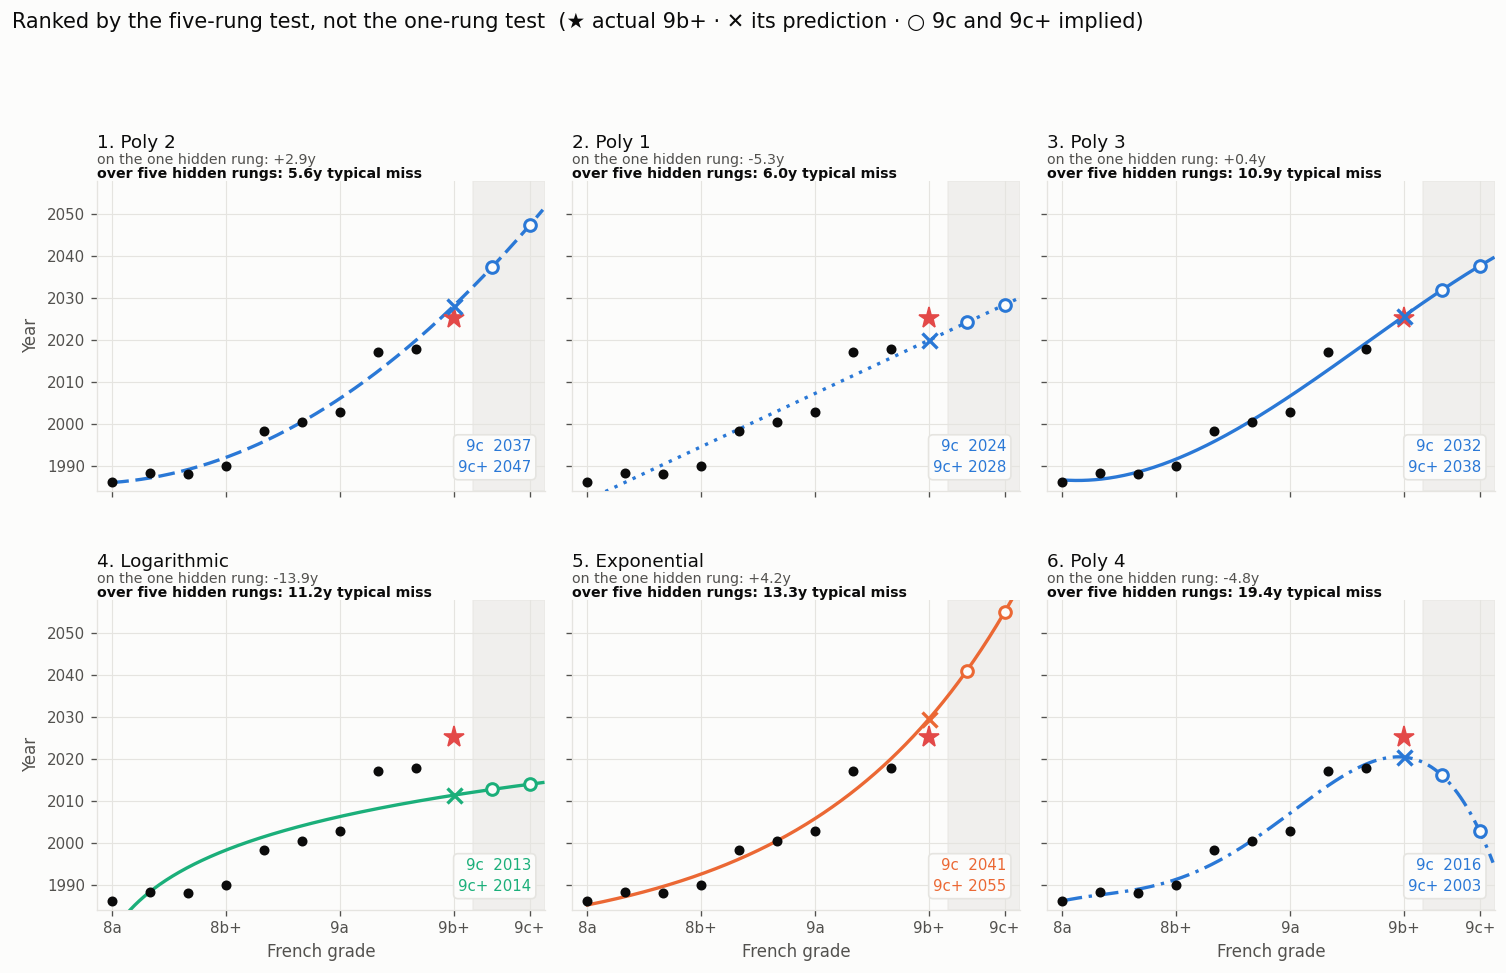

In [7]:
shape_scores = ROLL.set_index("method")
order = [m for m in ROLL["method"] if m in SHAPES]        # best-validating first
hold_by_model = holdout.set_index("model")

fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.1), dpi=120, facecolor=PAPER,
                         sharex=True, sharey=True)

for rank, (name, ax) in enumerate(zip(order, axes.ravel()), start=1):
    f, (color, ls) = models[name], STYLE[name]
    ax.set_facecolor(PAPER)
    ax.axvspan(9.5, 11.4, color=GRID, alpha=.5, zorder=0)
    ax.grid(color=GRID, lw=.7, zorder=1)

    ax.plot(grid_g, ORIGIN + f(grid_g) / 12, ls=ls, color=color, lw=2, zorder=3)
    ax.plot(x, ORIGIN + y / 12, "o", color=INK, ms=5, zorder=5)
    ax.plot([9], [ORIGIN + actual_9bp / 12], "*", color=RED, ms=13, zorder=6)
    # Above the star: where the two nearly coincide, that is the whole result.
    ax.plot([9], [ORIGIN + f(9.0) / 12], "x", color=color, ms=9, mew=2, zorder=7)

    miss1 = hold_by_model.loc[name, "miss (years)"]
    typ = shape_scores.loc[name, "typical miss (y)"]
    # Three stacked lines rather than a title plus two: a matplotlib title sits
    # at a fixed pad and lands on top of the first annotation.
    ax.text(0, 1.105, f"{rank}. {name}", transform=ax.transAxes,
            fontsize=11, color=INK)
    ax.text(0, 1.055, f"on the one hidden rung: {miss1:+.1f}y",
            transform=ax.transAxes, fontsize=8.5, color=MUTED)
    ax.text(0, 1.010, f"over five hidden rungs: {typ:.1f}y typical miss",
            transform=ax.transAxes, fontsize=8.5, color=INK, fontweight="bold")

    for step in (10, 11):
        ax.plot([step], [ORIGIN + f(step) / 12], "o", mfc=PAPER, mec=color,
                ms=7, mew=1.8, zorder=6)
    ax.text(0.97, 0.05, f"9c  {ORIGIN + f(10.) / 12:.0f}\n9c+ {ORIGIN + f(11.) / 12:.0f}",
            transform=ax.transAxes, fontsize=9, color=color, ha="right", va="bottom",
            linespacing=1.5,
            bbox=dict(facecolor=PAPER, edgecolor=GRID, boxstyle="round,pad=0.3"))

    for side in ("top", "right"): ax.spines[side].set_visible(False)
    for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

axes[0][0].set_xticks([0, 3, 6, 9, 11])
axes[0][0].set_xticklabels([LADDER[i] for i in (0, 3, 6, 9, 11)])
axes[0][0].set_xlim(-0.4, 11.4); axes[0][0].set_ylim(1984, 2058)
for ax in axes[:, 0]:
    ax.set_ylabel("Year", color=MUTED)
for ax in axes[1]:
    ax.set_xlabel("French grade", color=MUTED)

fig.suptitle("Ranked by the five-rung test, not the one-rung test  "
             "(★ actual 9b+ · ✕ its prediction · ○ 9c and 9c+ implied)",
             color=INK, fontsize=12.5, x=0.005, ha="left", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.93), h_pad=3.2)
plt.savefig(config.FIGURES_DIR / "female_model_panels.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

Read the two numbers at the top of each panel against each other:

- **Poly 2 and Poly 1** are unremarkable on the hidden rung (+2.9 and −5.3) and
  the best two curves over five. Neither can chase the wiggles, which is why
  neither is badly wrong anywhere.
- **Poly 3** is the reverse: +0.4 on the hidden rung, 10.9 typical. It is the
  panel that should change your mind about the first chart.
- **Poly 4** fits the nine training points most tightly of any shape here and has
  a typical miss of **19.4 years**. It also turns back on itself, so its 9c+
  (2028) lands *earlier* than its 9c (2028.2) — a curve running backwards
  through the grade it is being asked about.
- **Logarithmic and Exponential** fail in opposite directions and for the same
  reason: one flattens towards a ceiling the sport has not hit, the other
  accelerates away from data that has stopped accelerating.

## So when does 9c arrive?

The left panel puts the selected method's answer on the ladder with the bar it
earned: ±1 typical miss, taken from its five attempts. The grey column behind it
is every method that scored under six years, so the height of that column is the
disagreement among the methods worth listening to.

The right panel is why that method was chosen — the same scores as the table
above, drawn.

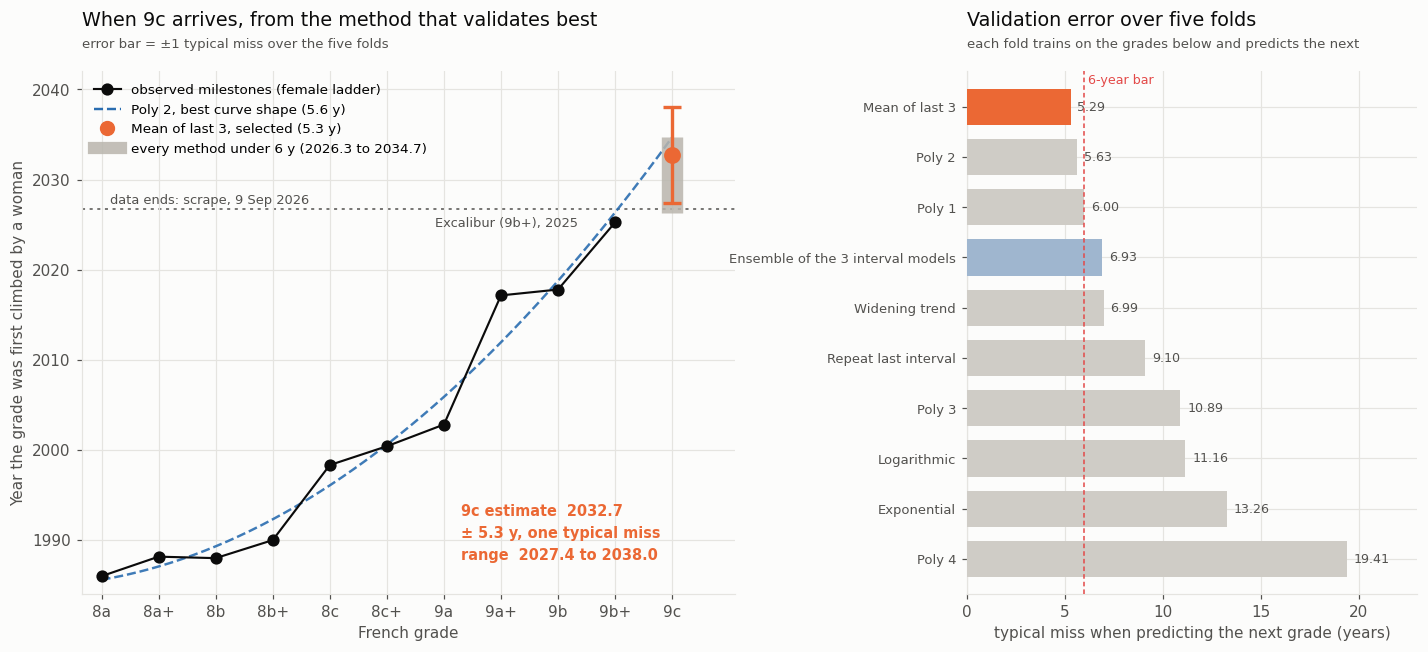

In [8]:
from matplotlib.lines import Line2D

SCRAPE = 2026 + (252 - 1) / 365.25          # the scrape date, 9 Sep 2026
CURVE_BLUE, GREY = "#2a6db0", "#b9b5ad"

BEST = ROLL.iloc[0]
best_name = BEST["method"]
best_9c = float(BEST["9c"])
best_miss = float(BEST["typical miss (y)"])
best_lo, best_hi = best_9c - best_miss, best_9c + best_miss
spread = ROLL[ROLL["typical miss (y)"] <= 6.0]["9c"].to_numpy(float)
curve_miss = float(ROLL.set_index("method").loc["Poly 2", "typical miss (y)"])

fig = plt.figure(figsize=(13.2, 6.6), dpi=110, facecolor=PAPER)
grid = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=.42,
                        left=.065, right=.985, top=.83, bottom=.11)
axL = fig.add_subplot(grid[0, 0])
axR = fig.add_subplot(grid[0, 1])
for ax in (axL, axR):
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

# --- left: the ladder, and where 9c lands ---
gg = np.linspace(0, 10, 300)
axL.plot(gg, [fit_on("Poly 2", GV, MV, YV, g) for g in gg], "--", color=CURVE_BLUE,
         lw=1.6, alpha=.9, zorder=2)
axL.plot(GV, YV, "-o", color=INK, lw=1.4, ms=7, zorder=5)
axL.axhline(SCRAPE, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
axL.text(0.15, SCRAPE + .7, "data ends: scrape, 9 Sep 2026", fontsize=8.5,
         color=MUTED, ha="left")
axL.vlines(10, spread.min(), spread.max(), color=GREY, lw=14, alpha=.85, zorder=3)
axL.errorbar([10], [best_9c], yerr=[best_miss], fmt="o", color=ORANGE, ms=10,
             elinewidth=2.2, capsize=6, capthick=2.2, zorder=6)
axL.annotate("Excalibur (9b+), 2025", (9, YV[-1]), xytext=(-118, -3),
             textcoords="offset points", fontsize=8.5, color=MUTED)
axL.text(.58, .06,
         f"9c estimate  {best_9c:.1f}\n"
         f"± {best_miss:.1f} y, one typical miss\n"
         f"range  {best_lo:.1f} to {best_hi:.1f}",
         transform=axL.transAxes, fontsize=9.5, color=ORANGE,
         fontweight="bold", va="bottom", linespacing=1.6)

handles = [
    Line2D([], [], color=INK, marker="o", lw=1.4, ms=7,
           label="observed milestones (female ladder)"),
    Line2D([], [], color=CURVE_BLUE, ls="--", lw=1.6,
           label=f"Poly 2, best curve shape ({curve_miss:.1f} y)"),
    Line2D([], [], color=ORANGE, marker="o", lw=0, ms=9,
           label=f"{best_name}, selected ({best_miss:.1f} y)"),
    Line2D([], [], color=GREY, lw=8, alpha=.85,
           label=f"every method under 6 y ({spread.min():.1f} to {spread.max():.1f})"),
]
axL.legend(handles=handles, frameon=False, fontsize=8.8, loc="upper left")
axL.set_xticks(range(11))
axL.set_xticklabels(LADDER[:11])
axL.set_xlim(-0.35, 11.1)
axL.set_ylim(1984, 2042)
axL.set_xlabel("French grade", color=MUTED)
axL.set_ylabel("Year the grade was first climbed by a woman", color=MUTED)
axL.set_title("When 9c arrives, from the method that validates best",
              color=INK, fontsize=12.5, loc="left", pad=30)
axL.text(0, 1.045, "error bar = ±1 typical miss over the five folds",
         transform=axL.transAxes, fontsize=8.7, color=MUTED)

# --- right: why that method was chosen ---
order = ROLL.sort_values("typical miss (y)", ascending=False)
cols = [ORANGE if m == best_name else ("#9fb6cf" if "Ensemble" in m else "#cfccc6")
        for m in order["method"]]
axR.barh(range(len(order)), order["typical miss (y)"], color=cols, zorder=3, height=.72)
axR.set_yticks(range(len(order)))
axR.set_yticklabels(order["method"], fontsize=8.6, color=MUTED)
for i, v in enumerate(order["typical miss (y)"]):
    axR.text(v + .35, i, f"{v:.2f}", va="center", fontsize=8.3, color=MUTED)
axR.axvline(6.0, color=RED, lw=1, ls=(0, (3, 2)), zorder=4)
axR.text(6.2, len(order) - .55, "6-year bar", fontsize=8.3, color=RED)
axR.set_xlim(0, 23)
axR.set_ylim(-.7, len(order) - .3)
axR.set_xlabel("typical miss when predicting the next grade (years)", color=MUTED)
axR.set_title("Validation error over five folds", color=INK, fontsize=12.5,
              loc="left", pad=30)
axR.text(0, 1.045, "each fold trains on the grades below and predicts the next",
         transform=axR.transAxes, fontsize=8.7, color=MUTED)

plt.savefig(config.FIGURES_DIR / "female_arrival_9c_9cplus.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

**9c around 2033, give or take about five years.**

The method that survives is the *average of the last three gaps*: take how long
the last three grades took (14.3, 0.7 and 7.5 years), average them (7.5), and add
that to Excalibur. It assumes nothing about the ladder's shape, and it beats
every curve fitted to the same data.

| | 9c | typical miss |
| --- | --- | --- |
| **Average of the last 3 gaps** (selected) | **2032.7** | **5.3 y** |
| Poly 2 (best curve) | 2034.7 | 5.6 y |
| Poly 1 | 2026.3 | 6.0 y |

The three methods that clear the six-year bar put 9c between **2026 and 2035**,
and the selected method's own track record spans **2027 to 2038**. That range is
a better-supported claim than any single year inside it.

### Each method on its own panel, two grades out

The chart above puts one estimate on the ladder. This puts the five best-scoring
methods side by side, one panel each, and pushes every one of them **two** steps
past Excalibur: to 9c, and then to 9c+.

Two things are drawn differently on purpose. **Poly 2 and Poly 1 are curves
through all ten rungs**, so they are drawn across the whole ladder — their
predictions are wherever those curves happen to cross 9c and 9c+. **The interval
models are not curves.** They know only the gaps between consecutive grades and
step forward from Excalibur, so they are drawn as a projection from 9b+ with
nothing behind it.

The second step is weaker evidence than the first, and is marked as such: the
error bar at 9c is the track record from the folds, and the 9c+ marker is hollow
because **nothing here validates a two-step jump.** Every fold predicted exactly
one grade ahead.

Only the top three cleared the six-year bar. The last two panels are shown for
contrast, and their scores are printed on them.

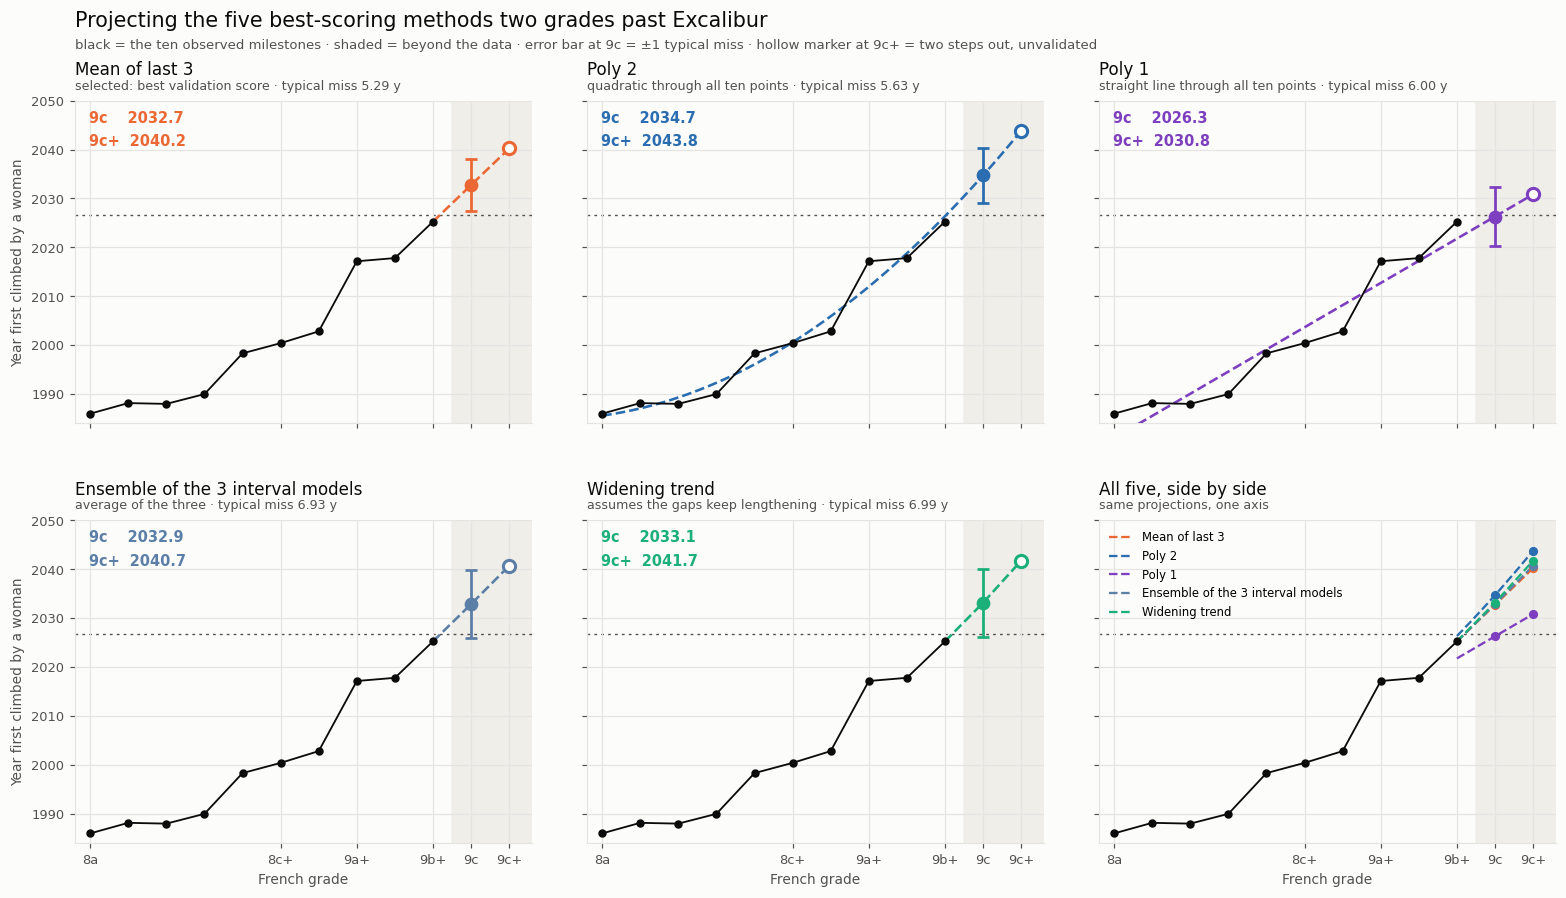

                           method  typical miss (y)      9c     9c+  implied gap
                   Mean of last 3              5.29 2032.74 2040.21         7.48
                           Poly 2              5.63 2034.71 2043.82         9.11
                           Poly 1              6.00 2026.30 2030.83         4.53
Ensemble of the 3 interval models              6.93 2032.86 2040.71         7.84
                   Widening trend              6.99 2033.15 2041.74         8.60


In [9]:
# predicted date at `target` steps, fitted on all ten rungs
def project(name, target):
    if name == "Ensemble of the 3 interval models":
        return float(np.mean([fit_on(m, GV, MV, YV, target) for m in INTERVALS]))
    return fit_on(name, GV, MV, YV, target)


# Ordered by the validation score. Scores are looked up from ROLL rather than
# retyped, so the panels and the table that scores them cannot drift apart.
SCORE = ROLL.set_index("method")["typical miss (y)"]
PANELS = [
    ("Mean of last 3", "#eb6834", "selected: best validation score"),
    ("Poly 2", "#2a6db0", "quadratic through all ten points"),
    ("Poly 1", "#7d3fbf", "straight line through all ten points"),
    ("Ensemble of the 3 interval models", "#5b7fa6", "average of the three"),
    ("Widening trend", "#1baf7a", "assumes the gaps keep lengthening"),
]
PANELS = [(n, float(SCORE[n]), c, b) for n, c, b in PANELS]
TICKS = [0, 5, 7, 9, 10, 11]
TICKLAB = ["8a", "8c+", "9a+", "9b+", "9c", "9c+"]
YLO, YHI = 1984, 2050

fig, axes = plt.subplots(2, 3, figsize=(14.4, 8.6), dpi=110, facecolor=PAPER,
                         sharex=True, sharey=True)
fig.subplots_adjust(left=.055, right=.99, top=.87, bottom=.085,
                    wspace=.12, hspace=.30)
for ax in axes.ravel():
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

for ax, (name, miss, color, blurb) in zip(axes.ravel(), PANELS):
    ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)       # beyond the data
    ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
    ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)

    p10, p11 = project(name, 10.0), project(name, 11.0)
    if name.startswith("Poly"):                            # a curve through the data
        gg = np.linspace(0, 11, 260)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.7,
                zorder=3)
    else:                                                  # a forward projection only
        ax.plot([9, 10, 11], [YV[-1], p10, p11], "--", color=color, lw=1.7,
                zorder=3)
    ax.errorbar([10], [p10], yerr=[miss], fmt="o", color=color, ms=8,
                elinewidth=1.8, capsize=4, capthick=1.8, zorder=6)
    ax.plot([11], [p11], "o", mfc=PAPER, mec=color, mew=2, ms=8, zorder=6)

    # the ladder rises steeply under both markers, so the dates go in the
    # panel corner rather than beside the points they belong to
    ax.text(.03, .97, f"9c    {p10:.1f}\n9c+  {p11:.1f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9.5,
            color=color, fontweight="bold", linespacing=1.7)
    ax.set_title(name, color=INK, fontsize=11, loc="left", pad=17)
    ax.text(0, 1.035, f"{blurb} · typical miss {miss:.2f} y",
            transform=ax.transAxes, fontsize=8.3, color=MUTED)

ax = axes.ravel()[5]                                       # all five together
ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)
ax.axhline(SCRAPE, color=MUTED, lw=.9, ls=(0, (2, 3)), zorder=1)
ax.plot(GV, YV, "-o", color=INK, lw=1.2, ms=4.5, zorder=4)
for name, miss, color, _ in PANELS:
    p10, p11 = project(name, 10.0), project(name, 11.0)
    if name.startswith("Poly"):
        gg = np.linspace(9, 11, 60)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.5,
                zorder=3)
    else:
        ax.plot([9, 10, 11], [YV[-1], p10, p11], "--", color=color, lw=1.5,
                zorder=3)
    ax.plot([10, 11], [p10, p11], "o", color=color, ms=5, zorder=5)
ax.set_title("All five, side by side", color=INK, fontsize=11, loc="left", pad=17)
ax.text(0, 1.035, "same projections, one axis", transform=ax.transAxes,
        fontsize=8.3, color=MUTED)
ax.legend(handles=[Line2D([], [], color=c, ls="--", lw=1.5, label=n)
                   for n, _, c, _ in PANELS],
          frameon=False, fontsize=7.6, loc="upper left")

for ax in axes.ravel():
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICKLAB)
    ax.set_xlim(-0.4, 11.6)
    ax.set_ylim(YLO, YHI)
for ax in axes[1]:
    ax.set_xlabel("French grade", color=MUTED, fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Year first climbed by a woman", color=MUTED, fontsize=9)

fig.suptitle("Projecting the five best-scoring methods two grades past Excalibur",
             color=INK, fontsize=13.5, x=.055, ha="left", y=.965)
fig.text(.055, .925,
         "black = the ten observed milestones · shaded = beyond the data · "
         "error bar at 9c = ±1 typical miss · "
         "hollow marker at 9c+ = two steps out, unvalidated",
         fontsize=8.7, color=MUTED)
plt.savefig(config.FIGURES_DIR / "female_projection_panels.png",
            facecolor=PAPER, bbox_inches="tight")
plt.show()

print(pd.DataFrame([{"method": n, "typical miss (y)": m,
                     "9c": project(n, 10.0), "9c+": project(n, 11.0),
                     "implied gap": project(n, 11.0) - project(n, 10.0)}
                    for n, m, _, _ in PANELS]).round(2).to_string(index=False))

**The five agree on 9c within nine years and disagree about 9c+ by thirteen.**
That widening is the reason to plot the second step at all: each method's
assumption about the *next* gap compounds when it is applied twice. Poly 1 keeps
the straight line's steady pace and stays earliest; Poly 2's curve keeps
steepening, so its second step costs the most; the interval models sit between,
adding seven to nine years each.

The two cautions the panels encode rather than state. **Only the 9c step was
tested** — every fold predicted one grade ahead, so the hollow 9c+ markers carry
no error bar the data has earned. And **9c+ would be the hardest route ever
climbed by anyone**, male or female: no 9c+ exists on either ladder, so its
"prediction" is a statement about the female ladder's rhythm continuing, not
about any route that could be climbed.

## An independent check that fits nothing

The estimate above rests on one test of five folds. Here is a cross-check that
uses no curve and no gap model at all: how far the female ladder has trailed the
male one, grade for grade.

In [10]:
men = pd.read_csv(config.PROCESSED_DIR / "milestones_as_consensus.csv")
men_yf = dict(zip(men["grade"], men["year_frac"]))
lag = lad.assign(male=lad["grade"].map(men_yf))
lag["lag_years"] = lag["year_frac"] - lag["male"]
lag = lag.dropna(subset=["male"])
print(lag[["grade", "male", "year_frac", "lag_years"]]
      .rename(columns={"year_frac": "female"}).round(1).to_string(index=False))

lv = lag["lag_years"].to_numpy()
male_9c = men_yf["9c"]
print(f"\nmedian lag {np.median(lv):.1f}y · mean of the last three {lv[-3:].mean():.1f}y "
      f"· lag at 9b+ {lv[-1]:.1f}y")
print(f"male 9c was {male_9c:.1f}, so the lag puts female 9c between "
      f"{male_9c + np.median(lv):.1f} and {male_9c + lv[-3:].mean():.1f}")
print("The male ladder has no 9c+, so this check cannot price female 9c+ at all.")

grade   male  female  lag_years
  8a+ 1983.0  1988.2        5.2
   8b 1984.8  1988.0        3.2
  8b+ 1985.0  1990.0        5.0
   8c 1987.0  1998.3       11.3
  8c+ 1990.2  2000.4       10.2
   9a 1990.4  2002.8       12.4
  9a+ 1996.0  2017.2       21.2
   9b 2008.7  2017.8        9.1
  9b+ 2012.8  2025.3       12.5

median lag 10.2y · mean of the last three 14.3y · lag at 9b+ 12.5y
male 9c was 2017.7, so the lag puts female 9c between 2027.8 and 2031.9
The male ladder has no 9c+, so this check cannot price female 9c+ at all.


The lag check lands on **2028 – 2032**, overlapping the selected method's
2027 – 2038 and sitting just below its central 2033. Two methods that share no
machinery — one projects gaps forward, the other only measures the distance
behind the men's ladder — agree on the early 2030s. That agreement is worth more
than either number alone.

## What this notebook supports, and what it does not

| | female 9c | female 9c+ |
| --- | --- | --- |
| Selected method (average of last 3 gaps) | **2032.7** | 2040.2 |
| Its own track record, ±1 typical miss | **2027 – 2038** | — |
| All methods scoring under six years | 2026 – 2035 | 2031 – 2044 |
| Lag behind the male ladder | 2028 – 2032 | not computable |
| **Read it as** | **the early-to-mid 2030s** | **untested; the 2040s at best a guess** |

The caveats that travel with it:

- **Ten data points and five tests.** Every warning notebook 02 carries about
  small samples applies here with one fewer point in the training set.
- **No method is reliable to better than about five years**, by its own track
  record — and the top three are separated by less than one.
- **9c+ is two steps past the data and nothing here validates two steps.** Every
  fold predicted one grade ahead. The men's notebook flags its 10a projection the
  same way and for the same reason.
- **The one event that would break this is the one none of these methods can
  see.** Every method missed 9a+ by 8 to 25 years because a fourteen-year stall
  was not predictable from anything before it. If the ladder is in another stall
  now, the error bar is measuring the wrong thing.
- **Two rungs rest on an external source alone** (Come Back, Choucas), three of
  the ten dates are year-only, and one ordering is unresolved.

### The two front-runners on their own

The panels above keep every method at the same small size so they can be
compared. These two charts pull out the pair worth remembering, each on a full
axis: **the average of the last three gaps**, which validates best of anything
here, and **Poly 2**, the best-scoring fitted curve. Same conventions as the
panels: filled marker at 9c with its typical-miss bar, hollow marker at 9c+
because a two-step jump is untested.

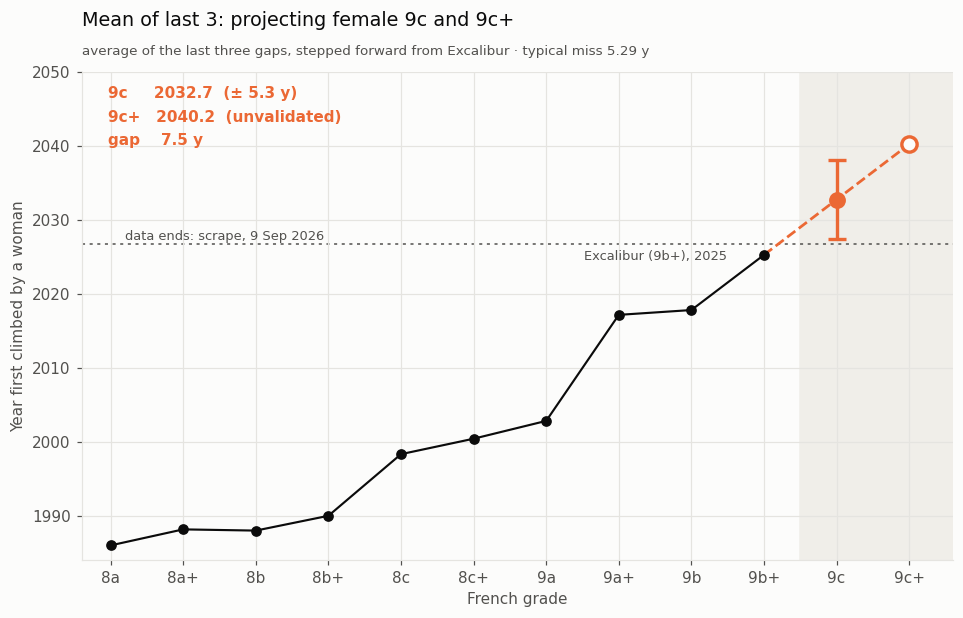

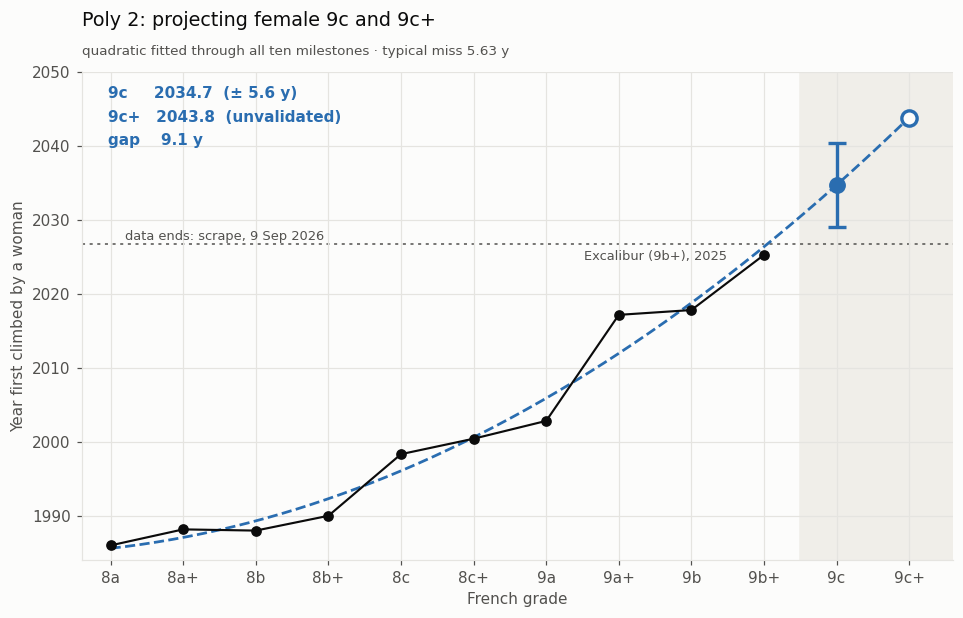

In [11]:
# The two methods worth keeping, one full-size chart each.
SOLO = [
    ("Mean of last 3", "#eb6834",
     "average of the last three gaps, stepped forward from Excalibur",
     "female_solo_mean_of_last_3.png"),
    ("Poly 2", "#2a6db0", "quadratic fitted through all ten milestones",
     "female_solo_poly2.png"),
]
YLO, YHI = 1984, 2050

for name, color, blurb, fname in SOLO:
    miss = float(SCORE[name])
    p10, p11 = project(name, 10.0), project(name, 11.0)

    fig, ax = plt.subplots(figsize=(9, 6), dpi=110, facecolor=PAPER)
    fig.subplots_adjust(left=.09, right=.97, top=.84, bottom=.10)
    ax.set_facecolor(PAPER)
    ax.grid(color=GRID, lw=.8, zorder=0)
    ax.tick_params(colors=MUTED)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)

    ax.axvspan(9.5, 11.6, color="#f0eee9", zorder=0)       # beyond the data
    ax.axhline(SCRAPE, color=MUTED, lw=1, ls=(0, (2, 3)), zorder=1)
    ax.text(.2, SCRAPE + .6, "data ends: scrape, 9 Sep 2026", fontsize=8.5,
            color=MUTED)
    ax.plot(GV, YV, "-o", color=INK, lw=1.4, ms=6, zorder=4)
    ax.annotate("Excalibur (9b+), 2025", (9, YV[-1]), xytext=(-118, -3),
                textcoords="offset points", fontsize=8.5, color=MUTED)

    if name == "Poly 2":                                   # a curve through the data
        gg = np.linspace(0, 11, 260)
        ax.plot(gg, [project(name, g) for g in gg], "--", color=color, lw=1.8,
                zorder=3)
    else:                                                  # a forward projection only
        ax.plot([9, 10, 11], [YV[-1], p10, p11], "--", color=color, lw=1.8,
                zorder=3)
    ax.errorbar([10], [p10], yerr=[miss], fmt="o", color=color, ms=10,
                elinewidth=2.2, capsize=6, capthick=2.2, zorder=6)
    ax.plot([11], [p11], "o", mfc=PAPER, mec=color, mew=2.2, ms=10, zorder=6)

    ax.text(.03, .97,
            f"9c     {p10:.1f}  (± {miss:.1f} y)\n"
            f"9c+   {p11:.1f}  (unvalidated)\n"
            f"gap    {p11 - p10:.1f} y",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            color=color, fontweight="bold", linespacing=1.7)

    ax.set_xticks(range(12))
    ax.set_xticklabels(LADDER)
    ax.set_xlim(-0.4, 11.6)
    ax.set_ylim(YLO, YHI)
    ax.set_xlabel("French grade", color=MUTED)
    ax.set_ylabel("Year first climbed by a woman", color=MUTED)
    ax.set_title(f"{name}: projecting female 9c and 9c+", color=INK,
                 fontsize=12.5, loc="left", pad=30)
    ax.text(0, 1.035, f"{blurb} · typical miss {miss:.2f} y",
            transform=ax.transAxes, fontsize=8.8, color=MUTED)
    plt.savefig(config.FIGURES_DIR / fname, facecolor=PAPER, bbox_inches="tight")
    plt.show()